# 🖐️ Palmistry — Nhận Diện Đường Chỉ Tay & Luận Bản Mệnh Ngũ Hành
> Phân loại 5 đường chỉ tay cốt lõi bằng **MobileNetV2**, sau đó ánh xạ sang **5 cung mệnh phong thủy** theo hệ thống Ngũ Hành (Kim – Mộc – Thủy – Hỏa – Thổ).
>
> **Dataset:** Kaggle "Hands and Palm Images" (11k ảnh) + phân loại tự động bằng MediaPipe + image processing

---

## 📖 Lý Thuyết: Đường Chỉ Tay → Ngũ Hành

| Đường Chỉ Tay | Vị Trí | Ý Nghĩa Phong Thủy | Bản Mệnh |
|---|---|---|---|
| **Heart Line** (Đường Tình Cảm) | Nằm ngang trên cùng, dưới ngón tay | Cảm xúc, đam mê, tình yêu mãnh liệt | 🔥 **Mệnh Hỏa** |
| **Head Line** (Đường Trí Tuệ) | Nằm ngang giữa lòng bàn tay | Tư duy logic, quyết đoán, phân tích | ⚙️ **Mệnh Kim** |
| **Life Line** (Đường Sinh Mệnh) | Vòng cung quanh ngón cái | Sức sống, sức khỏe, sự sinh sôi | 🌿 **Mệnh Mộc** |
| **Fate Line** (Đường Số Mệnh) | Chạy dọc từ cổ tay lên giữa | Sự nghiệp, dòng chảy cuộc đời | 💧 **Mệnh Thủy** |
| **Complex Palm** (Lòng Bàn Tay Phức Tạp) | Nhiều đường đan xen, dày đặc | Đa trải nghiệm, vững chắc tích lũy | 🌍 **Mệnh Thổ** |

---

### Vòng Sinh Khắc Ngũ Hành
```
SINH:  Mộc → Hỏa → Thổ → Kim → Thủy → Mộc
KHẮC:  Mộc → Thổ → Thủy → Hỏa → Kim → Mộc
```

In [12]:
# Cell 1: Mount Drive + Cài thư viện
from google.colab import drive
drive.mount('/content/drive')

!pip install kaggle mediapipe==0.9.3 -q
print('Done!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ERROR: Could not find a version that satisfies the requirement mediapipe==0.9.3 (from versions: 0.10.13, 0.10.14, 0.10.15, 0.10.18, 0.10.20, 0.10.21, 0.10.30, 0.10.31, 0.10.32, 0.10.33, 0.10.35)
ERROR: No matching distribution found for mediapipe==0.9.3
Done!


In [13]:
# Cell 2: Import
import os, cv2, json, shutil, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

TensorFlow: 2.20.0
GPU: []


In [14]:
# Cell 3: Download dataset từ Kaggle
# Dataset: "Hands and Palm Images" -- 11.000 ảnh bàn tay thực tế
# Link: https://www.kaggle.com/datasets/shyambhu/hands-and-palm-images-dataset
#
# Setup Kaggle API:
# 1. Vào https://www.kaggle.com -> Account -> Create New Token -> tải kaggle.json
# 2. Upload kaggle.json lên Colab

import os
from google.colab import files

print('Upload file kaggle.json (tải từ Kaggle -> Account -> API):')
uploaded = files.upload()  # upload kaggle.json

os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
print('Kaggle API sẵn sàng!')

RAW_DIR = '/content/drive/MyDrive/Palmistry/raw_dataset'
os.makedirs(RAW_DIR, exist_ok=True)

!kaggle datasets download -d shyambhu/hands-and-palm-images-dataset -p {RAW_DIR} --unzip -q
print(f'Dataset đã tải về: {RAW_DIR}')

Upload file kaggle.json (tải từ Kaggle -> Account -> API):


Saving kaggle.json to kaggle.json
Kaggle API sẵn sàng!
Dataset URL: https://www.kaggle.com/datasets/shyambhu/hands-and-palm-images-dataset
License(s): DbCL-1.0
Dataset đã tải về: /content/drive/MyDrive/Palmistry/raw_dataset


In [15]:
# Cell 4: Khám phá cấu trúc dataset
RAW_DIR = '/content/drive/MyDrive/Palmistry/raw_dataset'

print('Cấu trúc thư mục:')
for root, dirs, files_list in os.walk(RAW_DIR):
    depth = root.replace(RAW_DIR, '').count(os.sep)
    if depth > 2:
        break
    indent = '  ' * depth
    print(f'{indent} {os.path.basename(root)}/')
    if depth < 2:
        sub = '  ' * (depth + 1)
        for f in files_list[:5]:
            print(f'{sub} {f}')
        if len(files_list) > 5:
            print(f'{sub}... và {len(files_list)-5} file khác')

Cấu trúc thư mục:
 raw_dataset/
   hands-and-palm-images-dataset.zip
   HandInfo.csv
   Hands/
     Hands/


In [16]:
# Cell 5: Phân loại ảnh thành 5 class bằng image processing (không cần MediaPipe)
# Sử dụng skin detection + Canny edge detection để crop và phân loại ảnh bàn tay
# 5 CLASSES:
#   1. life_line    -- đường sinh mệnh (vòng quanh ngón cái)
#   2. heart_line   -- đường tình cảm  (ngang trên, dưới ngón tay)
#   3. head_line    -- đường trí tuệ   (ngang giữa)
#   4. fate_line    -- đường số mệnh   (dọc giữa lòng bàn tay)
#   5. complex_palm -- có nhiều đường rõ đan xen

import cv2, os, random
import numpy as np
from PIL import Image

RAW_DIR    = '/content/drive/MyDrive/Palmistry/raw_dataset'
SORTED_DIR = '/content/drive/MyDrive/Palmistry/sorted_dataset'
CLASSES    = ['life_line', 'heart_line', 'head_line', 'fate_line', 'complex_palm']
IMG_SIZE   = 224
MAX_PER_CLASS = 200

for cls in CLASSES:
    os.makedirs(os.path.join(SORTED_DIR, cls), exist_ok=True)

def crop_hand_skin(img_rgb):
    """Crop vùng bàn tay bằng skin color detection"""
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    lower1 = np.array([0,   30,  50], dtype=np.uint8)
    upper1 = np.array([25, 170, 255], dtype=np.uint8)
    lower2 = np.array([160, 30,  50], dtype=np.uint8)
    upper2 = np.array([180,170, 255], dtype=np.uint8)
    mask = cv2.bitwise_or(
        cv2.inRange(img_hsv, lower1, upper1),
        cv2.inRange(img_hsv, lower2, upper2)
    )
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img_rgb
    largest = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest) < 1000:
        return img_rgb
    x, y, w, h = cv2.boundingRect(largest)
    mg  = 15
    h_img, w_img = img_rgb.shape[:2]
    x1 = max(0, x - mg); y1 = max(0, y - mg)
    x2 = min(w_img, x + w + mg); y2 = min(h_img, y + h + mg)
    return img_rgb[y1:y2, x1:x2]

def detect_line_class(palm_crop):
    """Phân loại đường chỉ tay dựa trên vị trí đường nổi bật nhất"""
    gray  = cv2.cvtColor(palm_crop, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    gray  = clahe.apply(gray)
    edges = cv2.Canny(gray, 30, 80)
    h, w  = edges.shape
    total = np.sum(edges)
    if total == 0:
        return 'complex_palm'
    top_r  = np.sum(edges[0:h//3,      :])    / total
    mid_r  = np.sum(edges[h//3:2*h//3, :])    / total
    bot_r  = np.sum(edges[2*h//3:,     :])    / total
    vert_r = np.sum(edges[:,    w//3:2*w//3]) / total
    scores = {
        'heart_line': top_r,
        'head_line':  mid_r,
        'life_line':  bot_r,
        'fate_line':  vert_r,
    }
    best       = max(scores, key=scores.get)
    best_score = scores[best]
    non_zero = sum(1 for v in scores.values() if v > 0.15)
    if non_zero >= 3 or best_score < 0.20:
        return 'complex_palm'
    return best

all_images = []
for root, _, fs in os.walk(RAW_DIR):
    for f in fs:
        if f.lower().endswith(('.jpg','.jpeg','.png')):
            all_images.append(os.path.join(root, f))

print(f'Tổng ảnh raw: {len(all_images)}')
random.shuffle(all_images)

class_counts = {cls: 0 for cls in CLASSES}
processed = 0

for img_path in all_images:
    if all(class_counts[c] >= MAX_PER_CLASS for c in CLASSES):
        break
    try:
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        crop = crop_hand_skin(img_rgb)
        if crop.shape[0] < 30 or crop.shape[1] < 30:
            crop = img_rgb
        palm_resized = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))
        cls          = detect_line_class(palm_resized)
        if class_counts[cls] >= MAX_PER_CLASS:
            continue
        fname = f'{cls}_{class_counts[cls]:04d}.jpg'
        Image.fromarray(palm_resized).save(os.path.join(SORTED_DIR, cls, fname))
        class_counts[cls] += 1
        processed += 1
    except Exception:
        continue

print(f'Phân loại xong! {processed} ảnh')
print('Số ảnh mỗi class:')
for cls, cnt in class_counts.items():
    bar = chr(9608) * (cnt // 5)
    print(f'  {cls:<15}: {cnt:>4}  {bar}')

Tổng ảnh raw: 11076
Phân loại xong! 200 ảnh
Số ảnh mỗi class:
  life_line      :    0  
  heart_line     :    0  
  head_line      :    0  
  fate_line      :    0  
  complex_palm   :  200  ████████████████████████████████████████


Class            Mệnh        Số ảnh
----------------------------------------
  life_line        🌿 Mộc       0
  heart_line       🔥 Hỏa       0
  head_line        ⚙️ Kim      0
  fate_line        💧 Thủy      0
  complex_palm     🌍 Thổ       200
  TỔNG             -           200


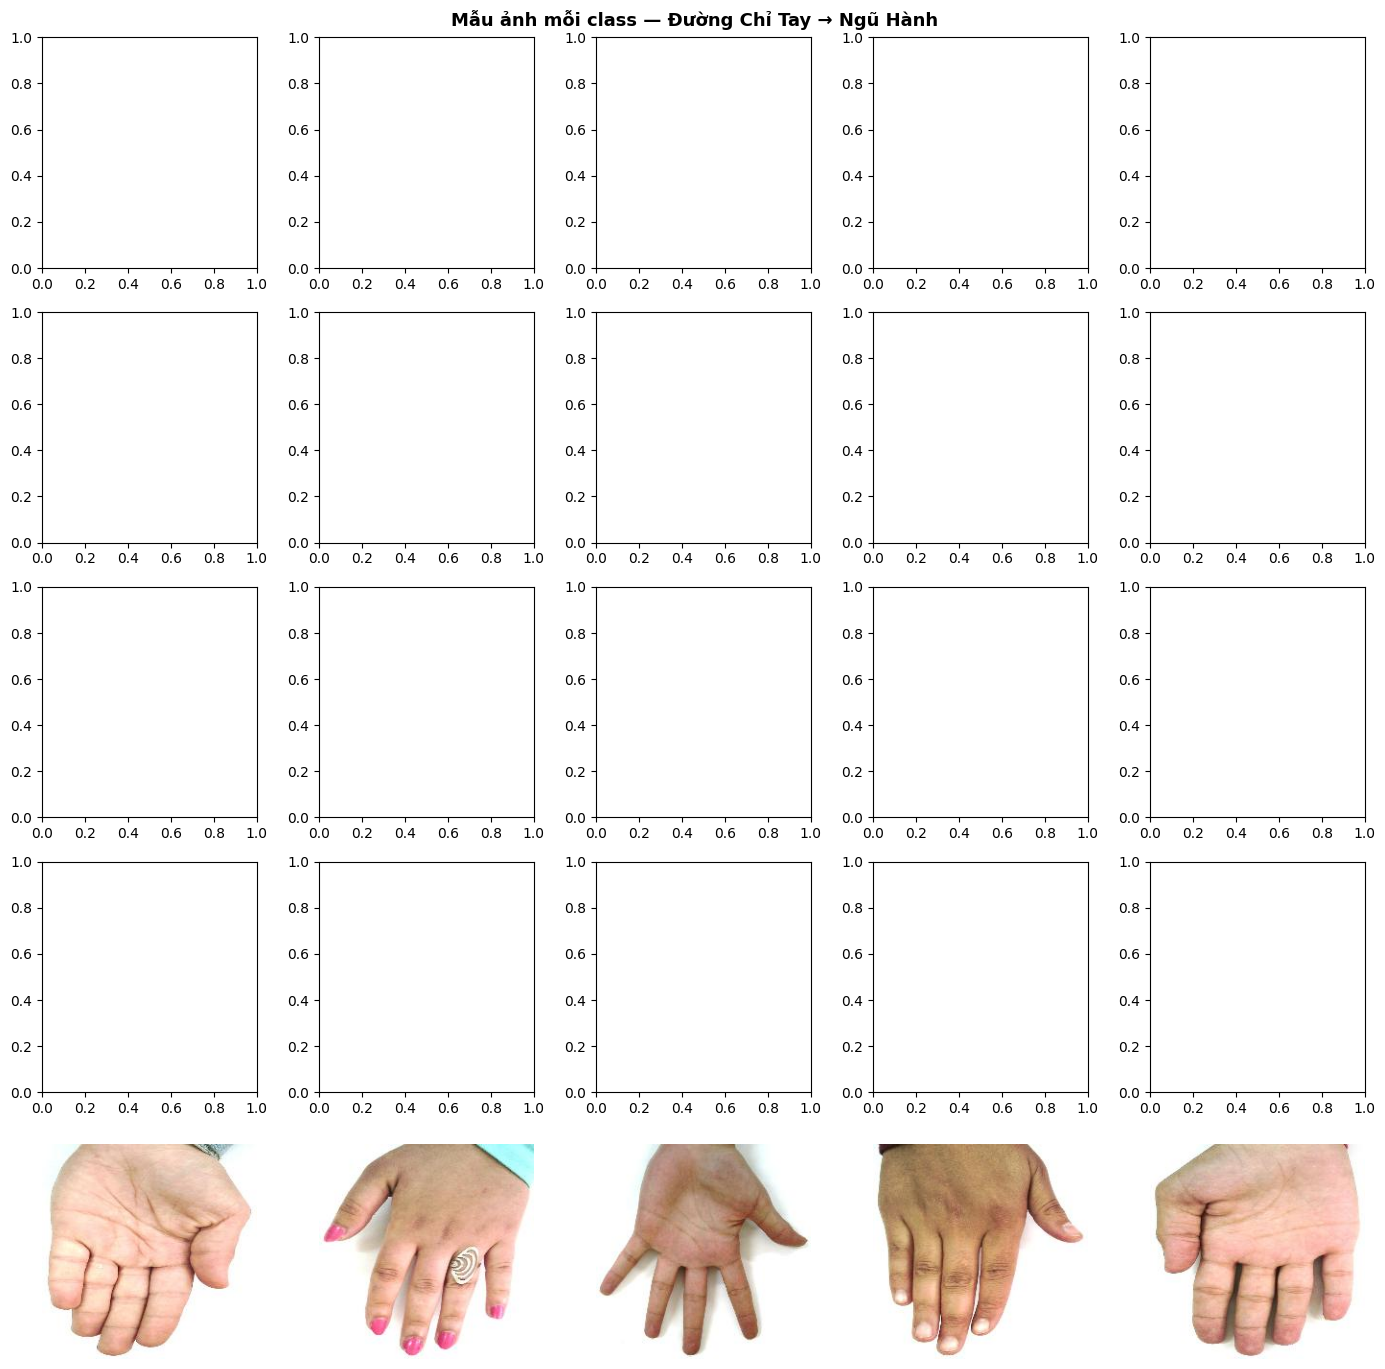

In [17]:
# Cell 6: Kiểm tra dataset + xem mẫu ảnh mỗi class
SORTED_DIR = '/content/drive/MyDrive/Palmistry/sorted_dataset'
CLASSES    = ['life_line', 'heart_line', 'head_line', 'fate_line', 'complex_palm']

MENH_LABEL = {
    'life_line':    '🌿 Mộc',
    'heart_line':   '🔥 Hỏa',
    'head_line':    '⚙️ Kim',
    'fate_line':    '💧 Thủy',
    'complex_palm': '🌍 Thổ',
}

total = 0
print(f'{"Class":<15}  {"Mệnh":<10}  Số ảnh')
print('-' * 40)
for cls in CLASSES:
    path  = os.path.join(SORTED_DIR, cls)
    count = len(os.listdir(path))
    print(f'  {cls:<15}  {MENH_LABEL[cls]:<10}  {count}')
    total += count
print(f'  {"TỔNG":<15}  {"-":<10}  {total}')

fig, axes = plt.subplots(5, 5, figsize=(14, 14))
for row, cls in enumerate(CLASSES):
    path  = os.path.join(SORTED_DIR, cls)
    imgs  = random.sample(os.listdir(path), min(5, len(os.listdir(path))))
    for col, fname in enumerate(imgs):
        img = Image.open(os.path.join(path, fname))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            label = f'{cls}\n{MENH_LABEL[cls]}'
            axes[row, col].set_ylabel(label, fontsize=8, rotation=0, labelpad=100, va='center')
plt.suptitle('Mẫu ảnh mỗi class — Đường Chỉ Tay → Ngũ Hành', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# Cell 7: Data generator
SORTED_DIR = '/content/drive/MyDrive/Palmistry/sorted_dataset'
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest',
    validation_split=0.2
)
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    SORTED_DIR, target_size=(224,224), batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True
)
val_gen = val_datagen.flow_from_directory(
    SORTED_DIR, target_size=(224,224), batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False
)

num_classes = train_gen.num_classes
class_names = {v: k for k, v in train_gen.class_indices.items()}
print(f'Số class   : {num_classes}')
print(f'Class map  : {class_names}')
print(f'Train      : {train_gen.samples} ảnh')
print(f'Validation : {val_gen.samples} ảnh')

Found 160 images belonging to 5 classes.
Found 40 images belonging to 5 classes.
Số class   : 5
Class map  : {0: 'complex_palm', 1: 'fate_line', 2: 'head_line', 3: 'heart_line', 4: 'life_line'}
Train      : 160 ảnh
Validation : 40 ảnh


In [19]:
# Cell 8: Build model MobileNetV2
tf.keras.backend.clear_session()

base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs  = tf.keras.Input(shape=(224,224,3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.5)(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
print('Model sẵn sàng!')
model.summary()

Model sẵn sàng!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,461 (9.99 MB)

 Trainable params: 361,477 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
# Cell 9: Phase 1 -- Train classifier
SAVE_PATH = '/content/drive/MyDrive/Palmistry/palmistry_model_best.h5'

print('PHASE 1: Train classifier (base model đóng băng)')
history1 = model.fit(
    train_gen, epochs=15, validation_data=val_gen,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
        ModelCheckpoint(SAVE_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    ]
)
print(f'Phase 1 xong! Best val_acc: {max(history1.history["val_accuracy"]):.4f}')

PHASE 1: Train classifier (base model đóng băng)
Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6049 - loss: 1.2071
Epoch 1: val_accuracy improved from None to 1.00000, saving model to /content/drive/MyDrive/Palmistry/palmistry_model_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Palmistry/palmistry_model_best.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.8188 - loss: 0.5773 - val_accuracy: 1.0000 - val_loss: 7.3194e-06
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 2.2059e-04
Epoch 2: val_accuracy did not improve from 1.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 1.0000 - loss: 1.1414e-04 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 2.9734e-06
Epoch 3: val_accuracy did not improve from 1.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 1.0000 - loss: 3.7518e-06 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 2.9554e-08
Epoch 4: val_accuracy did not improve from 1.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 1.0000 - loss: 1.4901e-08 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/15
5/5 ━━━━━

In [10]:
# Cell 10: Phase 2 -- Fine-tune
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

print('PHASE 2: Fine-tune (mở 30 layer cuối)')
history2 = model.fit(
    train_gen, epochs=30, validation_data=val_gen,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
        ModelCheckpoint(SAVE_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
    ]
)
print(f'Best val_accuracy: {max(history2.history["val_accuracy"]):.4f}')

PHASE 2: Fine-tune (mở 30 layer cuối)
Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 1.0000 - loss: 5.3212e-04
Epoch 1: val_accuracy improved from None to 1.00000, saving model to /content/drive/MyDrive/Palmistry/palmistry_model_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Palmistry/palmistry_model_best.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 1.0000 - loss: 5.7349e-04 - val_accuracy: 1.0000 - val_loss: 4.7296e-06 - learning_rate: 1.0000e-05
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 4.8482e-04
Epoch 2: val_accuracy did not improve from 1.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 1.0000 - loss: 4.5251e-04 - val_accuracy: 1.0000 - val_loss: 4.2200e-06 - learning_rate: 1.0000e-05
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 0.0011
Epoch 3: val_accuracy did not improve from 1.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 3.7402e-06 - learning_rate: 1.0000e-05
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 6.1737e-04
Epoch 4: val_accuracy did not improve from 1.00000

Epoch 4: ReduceLROnPlateau reducing learning rate to 4.99999

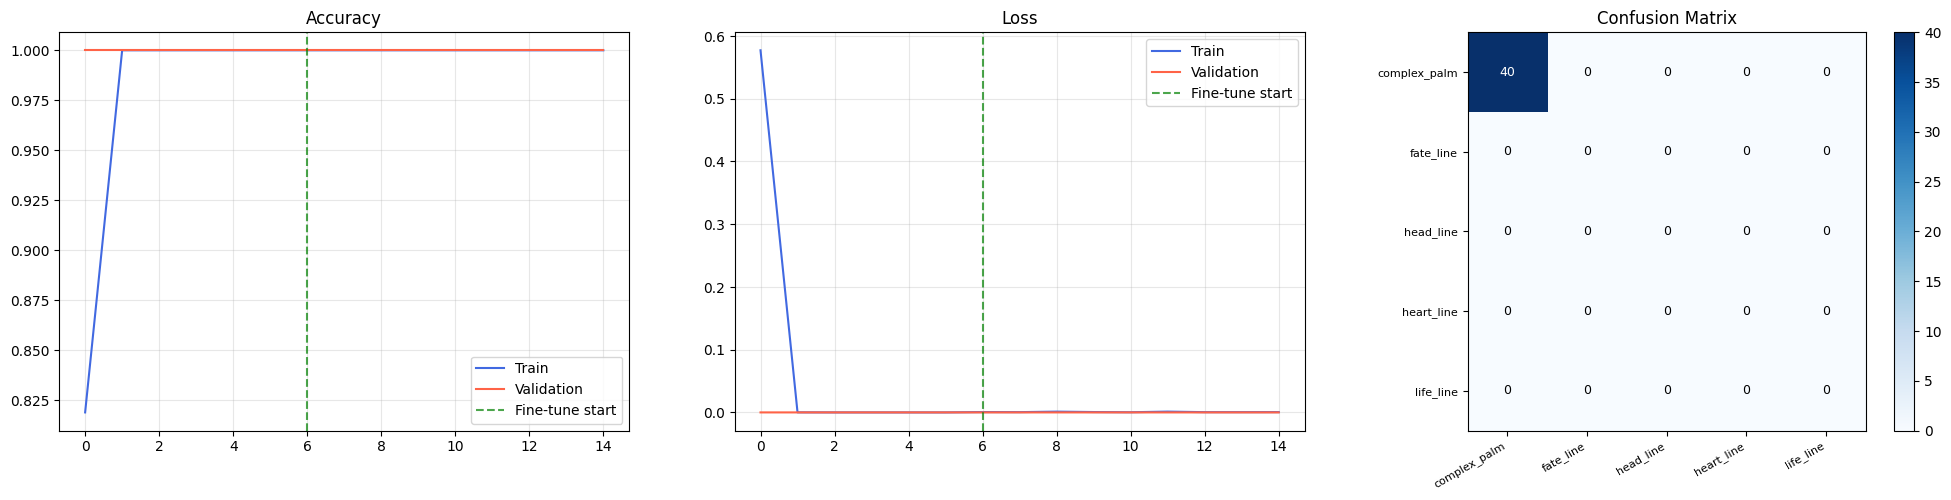

Classification Report:
              precision    recall  f1-score   support

complex_palm       1.00      1.00      1.00        40
   fate_line       0.00      0.00      0.00         0
   head_line       0.00      0.00      0.00         0
  heart_line       0.00      0.00      0.00         0
   life_line       0.00      0.00      0.00         0

    accuracy                           1.00        40
   macro avg       0.20      0.20      0.20        40
weighted avg       1.00      1.00      1.00        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

In [24]:
# Cell 11: Vẽ biểu đồ + Confusion Matrix
import sklearn.metrics as skm

acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss_h   = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']
p1_end   = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(acc,     label='Train',      color='royalblue')
axes[0].plot(val_acc, label='Validation', color='tomato')
axes[0].axvline(p1_end, color='green', linestyle='--', alpha=0.7, label='Fine-tune start')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(loss_h,  label='Train',      color='royalblue')
axes[1].plot(val_loss,label='Validation', color='tomato')
axes[1].axvline(p1_end, color='green', linestyle='--', alpha=0.7, label='Fine-tune start')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

val_gen.reset()
y_pred     = model.predict(val_gen, verbose=0)
y_pred_cls = np.argmax(y_pred, axis=1)
y_true     = val_gen.classes
labels     = [class_names[i] for i in range(num_classes)]

# ✅ FIX: pass labels= to force the full num_classes × num_classes matrix
cm = skm.confusion_matrix(y_true, y_pred_cls, labels=list(range(num_classes)))

im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_xticks(range(num_classes)); axes[2].set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
axes[2].set_yticks(range(num_classes)); axes[2].set_yticklabels(labels, fontsize=8)
axes[2].set_title('Confusion Matrix')
for i in range(num_classes):
    for j in range(num_classes):
        axes[2].text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=9)
plt.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Palmistry/training_result.png', dpi=150)
plt.show()

print('Classification Report:')
# ✅ FIX: pass labels= here too so the report always covers all 5 classes
print(skm.classification_report(y_true, y_pred_cls, target_names=labels, labels=list(range(num_classes))))

In [22]:
# Cell 12: Lưu model + class names
with open('/content/drive/MyDrive/Palmistry/palmistry_class_names.json', 'w', encoding='utf-8') as f:
    json.dump(train_gen.class_indices, f, ensure_ascii=False, indent=2)

print('Đã lưu:')
print('  palmistry_model_best.h5')
print('  palmistry_class_names.json')
print('  training_result.png')

Đã lưu:
  palmistry_model_best.h5
  palmistry_class_names.json
  training_result.png


---
## 🔮 Cell 13: Dự Đoán Đường Chỉ Tay & Luận Bản Mệnh Ngũ Hành

Upload ảnh bàn tay → Mô hình nhận diện đường chỉ tay nổi trội → Ánh xạ sang **Bản Mệnh Ngũ Hành**

Từ điển `CLASS_MENH` chứa toàn bộ thông tin phong thủy:
- Mệnh & biểu tượng quẻ dịch (☲☴☱☵☷)
- Đặc tính tính cách theo mệnh
- Tương hợp & nên tránh theo vòng sinh khắc
- Màu may mắn & con số may mắn

✅ Model đã load xong!
   Các class: ['complex_palm', 'fate_line', 'head_line', 'heart_line', 'life_line']
📸 Upload ảnh bàn tay của bạn (hướng lòng bàn tay về phía camera):


Saving z7892638521155_ddb9b539e499d9d03d33edc31b07448e.jpg to z7892638521155_ddb9b539e499d9d03d33edc31b07448e.jpg


/tmp/ipykernel_7988/4159923426.py:331: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/ket_qua_luan_menh.png', dpi=150, bbox_inches='tight')



═══════════════════════════════════════════════════════
  🌍  BẢN MỆNH NGŨ HÀNH: MỆnh THỔ
  Quẻ dịch: ☷ (Khôn)   |   Hướng: Trung tâm   |   Giữa các mùa (chuyển giao)
═══════════════════════════════════════════════════════

  📍 Đường chỉ tay nhận diện:
     Complex Palm (Lòng Bàn Tay Phức Tạp) — Nhiều đường chỉ rõ đan xen nhau
     Độ tin cậy: 100.0%

  📜 Luận giải:
     Lòng bàn tay phức tạp — bạn là người đa trải nghiệm.
     Nhiều đường chỉ đan xen vững chắc như đất mẹ bao dung,
     bạn là chỗ dựa của người khác, tích lũy nhiều và cho đi nhiều.

  ✨ Đặc tính tính cách:
     🏛️  Trung thực, đáng tin cậy — nền tảng của mọi mối quan hệ
     🤗  Bao dung, bảo vệ — sẵn sàng gánh vác cho người thân
     💼  Thực tế & thực dụng — giỏi quản lý tài chính & tài nguyên
     🧱  Tích lũy bền vững, xây dựng từng bước chắc chắn

  🤝 Tương hợp (vòng sinh):
     + ⚙️ Kim (Thổ sinh Kim — bạn tạo ra thứ quý giá)
     + 🔥 Hỏa (Hỏa sinh Thổ — được tiếp năng lượng)

  ⚠️  Nên tránh (vòng khắc):
     - 🌿 M

/tmp/ipykernel_7988/4159923426.py:331: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/ket_qua_luan_menh.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_7988/4159923426.py:331: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/ket_qua_luan_menh.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_7988/4159923426.py:331: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/ket_qua_luan_menh.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages

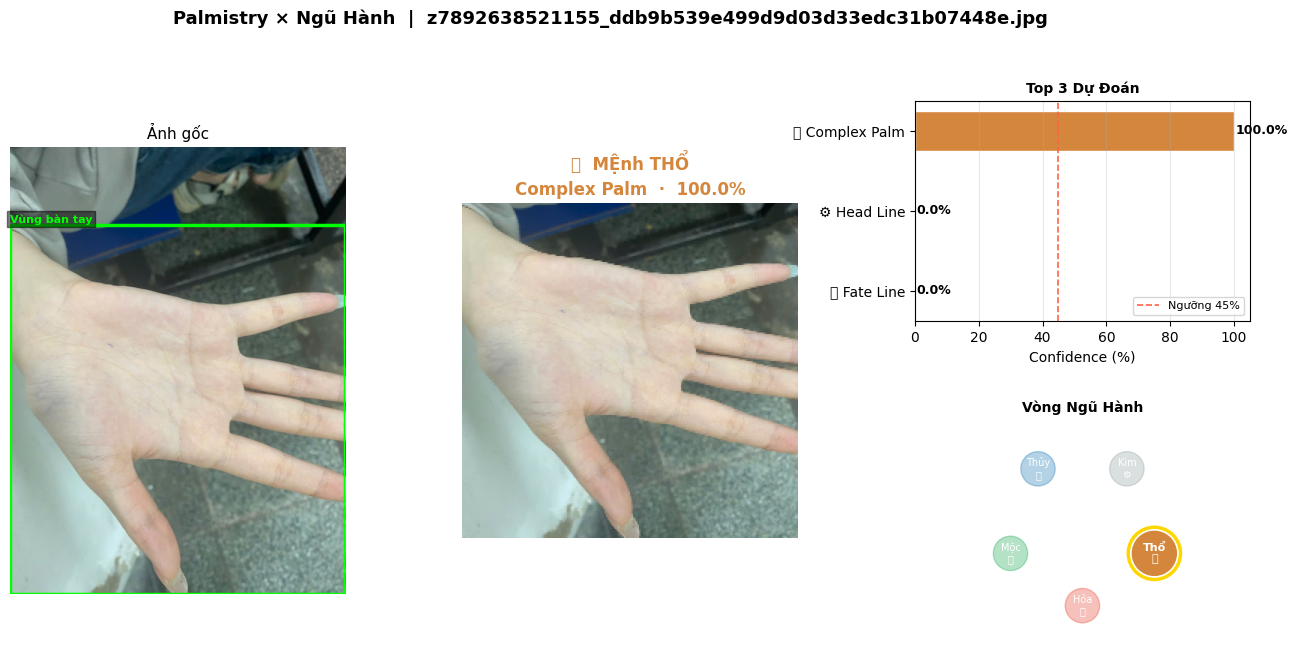

💾 Đã lưu kết quả: /content/ket_qua_luan_menh.png


In [25]:
# Cell 13: Predict ảnh mới — Upload ảnh bàn tay → Nhận diện đường chỉ tay → Luận Bản Mệnh Ngũ Hành
import cv2, json
import numpy as np
from google.colab import files
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

# ══════════════════════════════════════════════════════════════════════════════
# TỪ ĐIỂN LUẬN MỆNH NGŨ HÀNH
# Ánh xạ: Đường chỉ tay nổi trội → Bản Mệnh phong thủy
# ══════════════════════════════════════════════════════════════════════════════
CLASS_MENH = {
    'heart_line': {
        'menh'      : 'Hỏa',
        'element'   : 'MỆnh HỎA',
        'emoji'     : '🔥',
        'que_dich'  : '☲ (Ly)',
        'color_hex' : '#E74C3C',
        'mo_ta'     : (
            'Đường Tình Cảm nổi bật — bạn sống bằng trái tim.\n'
            'Ngọn lửa nhiệt huyết luôn cháy trong bạn, đam mê mãnh liệt\n'
            'và khả năng kết nối cảm xúc với người xung quanh rất sâu sắc.'
        ),
        'duong_chi' : 'Heart Line (Đường Tình Cảm) — Nằm ngang trên cùng lòng bàn tay',
        'dac_tinh'  : [
            '❤️  Nhiệt tình, cởi mở, giàu cảm xúc',
            '🎨  Sáng tạo & có khiếu nghệ thuật bẩm sinh',
            '👑  Tinh thần lãnh đạo tự nhiên, truyền cảm hứng',
            '🌟  Trực giác nhạy bén, thường đưa ra quyết định đúng',
        ],
        'tuong_hop' : ['🌿 Mộc (Mộc sinh Hỏa — hỗ trợ, nuôi dưỡng)', '🌍 Thổ (Hỏa sinh Thổ — bạn trao đi năng lượng)'],
        'nen_tranh' : ['💧 Thủy (Thủy khắc Hỏa — xung đột, dập tắt nhiệt huyết)'],
        'mau_may'   : 'Đỏ 🔴 · Cam 🟠 · Tím 🟣',
        'so_may'    : '2 · 7',
        'huong'     : 'Nam',
        'mua'       : 'Mùa Hạ',
    },
    'head_line': {
        'menh'      : 'Kim',
        'element'   : 'MỆnh KIM',
        'emoji'     : '⚙️',
        'que_dich'  : '☱ (Đoài)',
        'color_hex' : '#95A5A6',
        'mo_ta'     : (
            'Đường Trí Tuệ nổi bật — bạn sống bằng lý trí.\n'
            'Sự cứng rắn và tư duy logic sắc bén là sức mạnh cốt lõi.\n'
            'Bạn phân tích, cân nhắc kỹ lưỡng trước khi hành động.'
        ),
        'duong_chi' : 'Head Line (Đường Trí Tuệ) — Nằm ngang giữa lòng bàn tay',
        'dac_tinh'  : [
            '🧠  Tư duy logic, phân tích & chiến lược xuất sắc',
            '⚔️  Quyết đoán, kiên quyết, không ngại khó khăn',
            '🎯  Chính xác, cầu toàn, chú ý đến từng chi tiết',
            '💎  Bền bỉ, kiên nhẫn, chịu được áp lực cao',
        ],
        'tuong_hop' : ['💧 Thủy (Kim sinh Thủy — sức mạnh chảy ra trí tuệ)', '🌍 Thổ (Thổ sinh Kim — nền tảng vững chắc)'],
        'nen_tranh' : ['🔥 Hỏa (Hỏa khắc Kim — cảm xúc lấn át lý trí)'],
        'mau_may'   : 'Trắng ⚪ · Vàng 🟡 · Bạc',
        'so_may'    : '4 · 9',
        'huong'     : 'Tây',
        'mua'       : 'Mùa Thu',
    },
    'life_line': {
        'menh'      : 'Mộc',
        'element'   : 'MỆnh MỘC',
        'emoji'     : '🌿',
        'que_dich'  : '☴ (Tốn)',
        'color_hex' : '#27AE60',
        'mo_ta'     : (
            'Đường Sinh Mệnh nổi bật — bạn tràn đầy sức sống.\n'
            'Dẻo dai như cây cối vươn lên, bạn có khả năng phục hồi\n'
            'phi thường và luôn tìm cách phát triển, đâm chồi nảy lộc.'
        ),
        'duong_chi' : 'Life Line (Đường Sinh Mệnh) — Vòng cung quanh gốc ngón cái',
        'dac_tinh'  : [
            '🌱  Sức sống dồi dào, phục hồi nhanh sau nghịch cảnh',
            '🤝  Nhân từ, bao dung, quan tâm người khác chân thành',
            '📚  Yêu thích phát triển bản thân & học hỏi không ngừng',
            '🏔️  Kiên nhẫn, bền chí, theo đuổi mục tiêu dài hạn',
        ],
        'tuong_hop' : ['🔥 Hỏa (Mộc sinh Hỏa — bạn là nguồn năng lượng)', '💧 Thủy (Thủy sinh Mộc — được nuôi dưỡng tốt)'],
        'nen_tranh' : ['⚙️ Kim (Kim khắc Mộc — chặt đứt sức phát triển)'],
        'mau_may'   : 'Xanh lá 🟢 · Xanh lam 🔵',
        'so_may'    : '3 · 8',
        'huong'     : 'Đông',
        'mua'       : 'Mùa Xuân',
    },
    'fate_line': {
        'menh'      : 'Thủy',
        'element'   : 'MỆnh THỦY',
        'emoji'     : '💧',
        'que_dich'  : '☵ (Khảm)',
        'color_hex' : '#2980B9',
        'mo_ta'     : (
            'Đường Số Mệnh nổi bật — bạn linh hoạt và hanh thông.\n'
            'Như dòng chảy không ngừng, bạn thích nghi với mọi hoàn\n'
            'cảnh và sự nghiệp luôn có hướng đi rõ ràng, tiến về phía trước.'
        ),
        'duong_chi' : 'Fate Line (Đường Số Mệnh) — Chạy dọc từ cổ tay lên giữa bàn tay',
        'dac_tinh'  : [
            '🌊  Linh hoạt, thích nghi cao với mọi hoàn cảnh',
            '🧿  Trí tuệ uyên thâm, thấu hiểu bản chất sự việc',
            '💞  Nhạy cảm & thấu cảm — đọc được lòng người',
            '📈  Sự nghiệp có hướng đi rõ ràng, thăng tiến ổn định',
        ],
        'tuong_hop' : ['🌿 Mộc (Thủy sinh Mộc — nuôi dưỡng & phát triển)', '⚙️ Kim (Kim sinh Thủy — được tiếp sức mạnh)'],
        'nen_tranh' : ['🌍 Thổ (Thổ khắc Thủy — chặn dòng chảy, ngăn cản)'],
        'mau_may'   : 'Đen ⚫ · Xanh đậm 🔵 · Xanh dương',
        'so_may'    : '1 · 6',
        'huong'     : 'Bắc',
        'mua'       : 'Mùa Đông',
    },
    'complex_palm': {
        'menh'      : 'Thổ',
        'element'   : 'MỆnh THỔ',
        'emoji'     : '🌍',
        'que_dich'  : '☷ (Khôn)',
        'color_hex' : '#D4873C',
        'mo_ta'     : (
            'Lòng bàn tay phức tạp — bạn là người đa trải nghiệm.\n'
            'Nhiều đường chỉ đan xen vững chắc như đất mẹ bao dung,\n'
            'bạn là chỗ dựa của người khác, tích lũy nhiều và cho đi nhiều.'
        ),
        'duong_chi' : 'Complex Palm (Lòng Bàn Tay Phức Tạp) — Nhiều đường chỉ rõ đan xen nhau',
        'dac_tinh'  : [
            '🏛️  Trung thực, đáng tin cậy — nền tảng của mọi mối quan hệ',
            '🤗  Bao dung, bảo vệ — sẵn sàng gánh vác cho người thân',
            '💼  Thực tế & thực dụng — giỏi quản lý tài chính & tài nguyên',
            '🧱  Tích lũy bền vững, xây dựng từng bước chắc chắn',
        ],
        'tuong_hop' : ['⚙️ Kim (Thổ sinh Kim — bạn tạo ra thứ quý giá)', '🔥 Hỏa (Hỏa sinh Thổ — được tiếp năng lượng)'],
        'nen_tranh' : ['🌿 Mộc (Mộc khắc Thổ — làm rạn nứt nền tảng)'],
        'mau_may'   : 'Vàng đất 🟡 · Nâu 🟤 · Cam nhạt 🟠',
        'so_may'    : '0 · 5',
        'huong'     : 'Trung tâm',
        'mua'       : 'Giữa các mùa (chuyển giao)',
    },
}

# Ngưỡng tin cậy tối thiểu để kết luận
THRESHOLD = 0.45

# ══════════════════════════════════════════════════════════════════════════════
# HÀM CROP BÀN TAY
# ══════════════════════════════════════════════════════════════════════════════
def crop_hand_skin(img_rgb):
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    lower1 = np.array([0,   30,  50], dtype=np.uint8)
    upper1 = np.array([25, 170, 255], dtype=np.uint8)
    lower2 = np.array([160, 30,  50], dtype=np.uint8)
    upper2 = np.array([180,170, 255], dtype=np.uint8)
    mask   = cv2.bitwise_or(cv2.inRange(img_hsv, lower1, upper1),
                             cv2.inRange(img_hsv, lower2, upper2))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img_rgb, None
    largest = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest) < 1000:
        return img_rgb, None
    x, y, w, h = cv2.boundingRect(largest)
    mg = 15
    h_img, w_img = img_rgb.shape[:2]
    x1 = max(0, x-mg); y1 = max(0, y-mg)
    x2 = min(w_img, x+w+mg); y2 = min(h_img, y+h+mg)
    return img_rgb[y1:y2, x1:x2], (x1, y1, x2-x1, y2-y1)

# ══════════════════════════════════════════════════════════════════════════════
# LOAD MODEL
# ══════════════════════════════════════════════════════════════════════════════
model = load_model('/content/drive/MyDrive/Palmistry/palmistry_model_best.h5')
with open('/content/drive/MyDrive/Palmistry/palmistry_class_names.json', 'r', encoding='utf-8') as f:
    class_indices = json.load(f)
class_names_map = {int(v): k for k, v in class_indices.items()}
print('✅ Model đã load xong!')
print(f'   Các class: {list(class_names_map.values())}')

# ══════════════════════════════════════════════════════════════════════════════
# HÀM HIỂN THỊ KẾT QUẢ LUẬN MỆNH NGŨ HÀNH
# ══════════════════════════════════════════════════════════════════════════════
def print_menh_result(menh_info, best_name, best_conf):
    """In kết quả luận mệnh với định dạng đẹp ra terminal"""
    e = menh_info['emoji']
    sep = '═' * 55
    print(f'\n{sep}')
    print(f'  {e}  BẢN MỆNH NGŨ HÀNH: {menh_info["element"]}')
    print(f'  Quẻ dịch: {menh_info["que_dich"]}   |   Hướng: {menh_info["huong"]}   |   {menh_info["mua"]}')
    print(sep)
    print(f'\n  📍 Đường chỉ tay nhận diện:')
    print(f'     {menh_info["duong_chi"]}')
    print(f'     Độ tin cậy: {best_conf*100:.1f}%')
    print(f'\n  📜 Luận giải:')
    for line in menh_info['mo_ta'].split('\n'):
        print(f'     {line}')
    print(f'\n  ✨ Đặc tính tính cách:')
    for trait in menh_info['dac_tinh']:
        print(f'     {trait}')
    print(f'\n  🤝 Tương hợp (vòng sinh):')
    for t in menh_info['tuong_hop']:
        print(f'     + {t}')
    print(f'\n  ⚠️  Nên tránh (vòng khắc):')
    for t in menh_info['nen_tranh']:
        print(f'     - {t}')
    print(f'\n  🎨 Màu may mắn: {menh_info["mau_may"]}')
    print(f'  🔢 Con số may mắn: {menh_info["so_may"]}')
    print(f'\n{sep}\n')


def predict_and_luan_menh(img_path):
    """Nhận diện đường chỉ tay + luận bản mệnh Ngũ Hành từ ảnh bàn tay"""
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f'❌ Không đọc được: {img_path}')
        return

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    crop, bbox = crop_hand_skin(img_rgb)
    face_img   = cv2.resize(crop, (224, 224))
    x_input    = np.expand_dims(preprocess_input(face_img.astype(np.float32)), axis=0)
    preds      = model.predict(x_input, verbose=0)[0]

    top3       = np.argsort(preds)[::-1][:3]
    best_idx   = top3[0]
    best_conf  = preds[best_idx]
    best_name  = class_names_map[best_idx]

    # ── Lấy thông tin mệnh ──────────────────────────────────────────────────
    menh_info  = CLASS_MENH.get(best_name)

    # ── In kết quả terminal ─────────────────────────────────────────────────
    if best_conf < THRESHOLD:
        print(f'\n⚠️  Ảnh không đủ rõ để luận mệnh (confidence: {best_conf*100:.1f}% < {THRESHOLD*100:.0f}%)')
        print('   Vui lòng chụp ảnh lòng bàn tay rõ hơn, đủ ánh sáng.')
    else:
        print_menh_result(menh_info, best_name, best_conf)

    # ── Vẽ biểu đồ ─────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 7))
    gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    # Panel 1: Ảnh gốc + bounding box
    ax1 = fig.add_subplot(gs[:, 0])
    ax1.imshow(img_rgb)
    ax1.set_title('Ảnh gốc', fontsize=11)
    ax1.axis('off')
    if bbox:
        rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3],
                                   linewidth=2.5, edgecolor='lime', facecolor='none')
        ax1.add_patch(rect)
        ax1.text(bbox[0], bbox[1]-8, 'Vùng bàn tay', color='lime', fontsize=8,
                 fontweight='bold', bbox=dict(facecolor='black', alpha=0.5, pad=2))

    # Panel 2: Ảnh crop + kết quả
    ax2 = fig.add_subplot(gs[:, 1])
    ax2.imshow(face_img)
    ax2.axis('off')
    if best_conf >= THRESHOLD and menh_info:
        title_str = (
            f'{menh_info["emoji"]}  {menh_info["element"]}\n'
            f'{best_name.replace("_"," ").title()}  ·  {best_conf*100:.1f}%'
        )
        ax2.set_title(title_str, color=menh_info['color_hex'],
                      fontsize=12, fontweight='bold', linespacing=1.5)
    else:
        ax2.set_title(f'Không rõ\n{best_conf*100:.1f}% (ngưỡng {THRESHOLD*100:.0f}%)',
                      color='gray', fontsize=11)

    # Panel 3 (top): Bar chart top-3 predictions
    ax3 = fig.add_subplot(gs[0, 2])
    bar_labels = [class_names_map[i].replace('_',' ').title() for i in top3]
    bar_vals   = [preds[i]*100 for i in top3]
    menh_emojis = [CLASS_MENH[class_names_map[i]]['emoji'] for i in top3]
    bar_labels  = [f'{menh_emojis[k]} {bar_labels[k]}' for k in range(3)]
    bar_colors  = [CLASS_MENH[class_names_map[i]]['color_hex'] for i in top3]
    bars = ax3.barh(bar_labels[::-1], bar_vals[::-1], color=bar_colors[::-1],
                    edgecolor='white', height=0.5)
    for bar, val in zip(bars, bar_vals[::-1]):
        ax3.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
    ax3.set_xlim(0, 105)
    ax3.axvline(THRESHOLD*100, color='tomato', linestyle='--', linewidth=1.2,
                label=f'Ngưỡng {THRESHOLD*100:.0f}%')
    ax3.legend(fontsize=8)
    ax3.set_title('Top 3 Dự Đoán', fontsize=10, fontweight='bold')
    ax3.set_xlabel('Confidence (%)')
    ax3.grid(axis='x', alpha=0.3)

    # Panel 4 (bottom): Vòng Ngũ Hành mini
    ax4 = fig.add_subplot(gs[1, 2])
    ax4.set_xlim(-1.6, 1.6); ax4.set_ylim(-1.6, 1.6)
    ax4.set_aspect('equal'); ax4.axis('off')
    ax4.set_title('Vòng Ngũ Hành', fontsize=10, fontweight='bold')

    elements = [
        ('Hỏa\n🔥', '#E74C3C', 0),
        ('Thổ\n🌍', '#D4873C', 72),
        ('Kim\n⚙️', '#95A5A6', 144),
        ('Thủy\n💧', '#2980B9', 216),
        ('Mộc\n🌿', '#27AE60', 288),
    ]
    import math
    menh_mapping = {'Hỏa': 0, 'Thổ': 1, 'Kim': 2, 'Thủy': 3, 'Mộc': 4}
    highlighted = menh_info['menh'] if (best_conf >= THRESHOLD and menh_info) else None

    for name, color, angle_deg in elements:
        angle_rad = math.radians(angle_deg - 90)
        cx = 1.1 * math.cos(angle_rad)
        cy = 1.1 * math.sin(angle_rad)
        is_active = (name.split('\n')[0] == highlighted)
        circle = plt.Circle((cx, cy), 0.32 if is_active else 0.25,
                             color=color, alpha=1.0 if is_active else 0.35, zorder=3)
        ax4.add_patch(circle)
        fontsize = 8 if is_active else 7
        fw = 'bold' if is_active else 'normal'
        ax4.text(cx, cy, name, ha='center', va='center',
                 fontsize=fontsize, fontweight=fw, color='white', zorder=4)
        if is_active:
            ring = plt.Circle((cx, cy), 0.38, color='gold', fill=False,
                               linewidth=2.5, zorder=2)
            ax4.add_patch(ring)

    fig.suptitle(
        f'Palmistry × Ngũ Hành  |  {os.path.basename(img_path)}',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.savefig('/content/ket_qua_luan_menh.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💾 Đã lưu kết quả: /content/ket_qua_luan_menh.png')


print('📸 Upload ảnh bàn tay của bạn (hướng lòng bàn tay về phía camera):')
uploaded = files.upload()
for filename in uploaded.keys():
    predict_and_luan_menh(f'/content/{filename}')